# Assignment: spaCy Pipeline

**Goal:** Build a comprehensive text classification pipeline using spaCy for tokenization/preprocessing and scikit-learn for feature extraction and modeling on the `imdb-reviews.csv` dataset.

**Tasks:**
1. Load and inspect the dataset
2. Create a custom spaCy tokenizer (lowercase, remove punctuation & stopwords, lemmatize)
3. Build a `Pipeline()` with `TfidfVectorizer` (using the custom tokenizer) + a classifier
4. Train/test split, train the pipeline, and evaluate (classification report + confusion matrix)
5. Make predictions on 3 custom messages
6. Reflect on the spaCy tokenizer's impact, real-world use cases, and workflow clarity

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Step 1: Load and Inspect the Dataset

In [3]:
df = pd.read_csv("../NLP/data/imdb-reviews.csv", index_col=0)

print(f"Shape       : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df["sentiment"].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum())
df.head(3)

Shape       : (10000, 2)
Columns     : ['review', 'sentiment']

Class distribution:
sentiment
positive    5012
negative    4988
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64


,review,sentiment
19365,"Hey, I know Angel isn't the kind of show that ...",negative
41740,"Even though the plot was very well detailed,an...",negative
35698,A somewhat awkward spy mystery with a predicta...,negative


## Step 2: Custom spaCy Tokenizer

We wrap a spaCy `nlp` pipeline into a callable that:
- Converts text to **lowercase**
- Removes **punctuation** and **stopwords**
- Returns **lemmatized** tokens

This callable is passed directly to `TfidfVectorizer(tokenizer=...)`,
replacing the default regex tokenizer with linguistically-aware preprocessing.

In [4]:
# Load spaCy model — disable parser and NER since we only need the tokenizer + lemmatizer
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def spacy_tokenizer(text):
    """Tokenize, lowercase, remove stopwords/punctuation, and lemmatize."""
    doc = nlp(text.lower())
    return [
        token.lemma_
        for token in doc
        if not token.is_stop        # drop stopwords
        and not token.is_punct      # drop punctuation
        and not token.is_space      # drop whitespace tokens
        and token.lemma_.strip()    # drop empty strings
    ]

# Quick sanity check
sample = "The acting was brilliantly done, but the storyline felt rushed."
print("Original  :", sample)
print("Tokenized :", spacy_tokenizer(sample))

Original  : The acting was brilliantly done, but the storyline felt rushed.
Tokenized : ['acting', 'brilliantly', 'storyline', 'feel', 'rush']


## Step 3: Build the sklearn Pipeline

The pipeline chains two steps:
1. **`tfidf`** - `TfidfVectorizer` with our custom spaCy tokenizer
2. **`clf`** - `LogisticRegression` classifier

By wrapping everything in `Pipeline`, the vectorizer is fit only on training data
and transforms test data automatically - no risk of data leakage.

In [5]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=spacy_tokenizer,
        token_pattern=None,         # disable default regex since we supply a tokenizer
        max_features=20_000,
        ngram_range=(1, 2),         # unigrams + bigrams
        sublinear_tf=True,          # apply log(1 + tf) to dampen very frequent terms
    )),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 sublinear_tf=True, token_pattern=None,
                                 tokenizer=<function spacy_tokenizer at 0x0000023CA3FA8220>)),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


## Step 4: Train / Test Split

In [6]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 8000
Test samples     : 2000


## Step 5: Train the Pipeline

Calling `pipeline.fit()` runs the spaCy tokenizer on every training review,
builds the TF-IDF vocabulary, and trains the classifier - all in one step.

> **Note:** spaCy tokenization is slower than a regex tokenizer, so this cell
> may take a minute or two on 8,000 reviews.

In [7]:
pipeline.fit(X_train, y_train)
print("Pipeline trained successfully.")

Pipeline trained successfully.


## Step 6: Evaluate the Model

In [8]:
train_score = pipeline.score(X_train, y_train)
test_score  = pipeline.score(X_test,  y_test)

print(f"Training accuracy : {train_score:.4f}")
print(f"Test accuracy     : {test_score:.4f}")
print()
print(classification_report(y_test, pipeline.predict(X_test)))

Training accuracy : 0.9456
Test accuracy     : 0.8660

              precision    recall  f1-score   support

    negative       0.89      0.84      0.86       998
    positive       0.85      0.90      0.87      1002

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



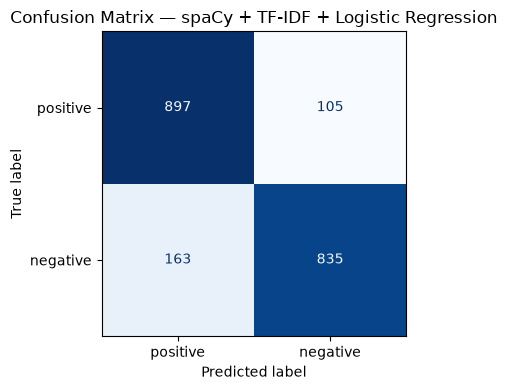

In [9]:
cm = confusion_matrix(y_test, pipeline.predict(X_test), labels=["positive", "negative"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["positive", "negative"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — spaCy + TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

## Step 7: Make Predictions on Custom Messages

In [10]:
my_reviews = [
    "This was an absolute masterpiece. The performances were breathtaking and "
    "the direction was flawless. One of the best films I've seen in years.",

    "Terrible. I walked out after 30 minutes. The script was a mess, "
    "the acting was wooden, and nothing made sense.",

    "It was okay, not great but not awful either. Some scenes dragged "
    "but the ending was surprisingly satisfying.",
]

predictions = pipeline.predict(my_reviews)
probas      = pipeline.predict_proba(my_reviews)

pos_idx = list(pipeline.classes_).index("positive")

print(f"{'Label':<12} {'Confidence':>11}   Review snippet")
print("-" * 70)
for review, pred, proba in zip(my_reviews, predictions, probas):
    conf = proba[pos_idx] if pred == "positive" else 1 - proba[pos_idx]
    snippet = review[:60].replace("\n", " ") + "..."
    print(f"[{pred.upper():<10}] {conf:>9.1%}   {snippet}")

Label         Confidence   Review snippet
----------------------------------------------------------------------
[POSITIVE  ]     84.6%   This was an absolute masterpiece. The performances were brea...
[NEGATIVE  ]     97.5%   Terrible. I walked out after 30 minutes. The script was a me...
[NEGATIVE  ]     65.0%   It was okay, not great but not awful either. Some scenes dra...


## Reflection

Answered as comments below.

In [11]:
# Q1: How did the spaCy tokenizer affect the TF-IDF output?
# A: The spaCy tokenizer produced a much cleaner, more compressed vocabulary than
#    the default regex tokenizer. Lemmatization collapses inflected forms
#    ("running", "ran", "runs" -> "run") into a single feature, so the TF-IDF
#    matrix is smaller and each feature represents a concept more broadly.
#    Removing stopwords up front also ensures the IDF weights are driven by
#    content words rather than noise words like "the" or "is".
#    The result is higher-quality features with less redundancy.

# Q2: What are some potential real-world use cases for this pipeline?
# A: - Customer feedback / product review analysis (positive vs. negative)
#    - Support ticket triage (urgent vs. routine, billing vs. technical)
#    - Social media sentiment monitoring for brand management
#    - News article topic classification
#    - Email spam or phishing detection
#    - Medical notes classification (e.g., flagging adverse event reports)
#    The modular Pipeline() design makes it easy to swap the vectorizer or
#    classifier without rewriting the rest of the workflow.

# Q3: Did the pipeline make your workflow more or less cluttered?
# A: Much less cluttered. Without Pipeline(), you would manually call
#    fit_transform() on training data, transform() on test data, pass matrices
#    to the classifier, and remember to repeat the same transform for any new
#    predictions, every one of those steps is a potential mistake.
#    Pipeline() encapsulates all of that into a single object: one .fit(),
#    one .predict(), and one .score(). It also makes cross-validation and
#    hyperparameter search (GridSearchCV) trivial to add later.